# Weather Prediction — A Complete Data Mining Project

## Business Context
Accurate weather forecasting impacts agriculture, logistics, energy, and daily life. This final project builds a machine learning pipeline that fetches real historical weather data via API, engineers time-series features, and predicts key meteorological variables.

**Key objectives:**
- Data acquisition from Open-Meteo API
- Feature engineering for time series (lag features, rolling statistics)
- Random Forest regression with multi-target prediction
- Complete end-to-end data mining workflow


## 1. 数据获取与数据清理

In [5]:
import requests
import pandas as pd
import time

def fetch_chengdu_weather(start_date, end_date):
    """
    使用 Open-Meteo API 获取成都的历史气象数据
    无需 API Key，免费使用
    """
    # 成都的经纬度
    lat = 30.6586
    lon = 104.0648
    
    # API 接口地址
    url = "https://archive-api.open-meteo.com/v1/archive"
    
    # 请求参数 (根据论文需求选择的特征)
    params = {
        "latitude": lat,
        "longitude": lon,
        "start_date": start_date,
        "end_date": end_date,
        # 需要获取的变量：最高温、最低温、平均温、降雨量、最大风速、短波辐射(代表光照)
        "daily": "temperature_2m_max,temperature_2m_min,temperature_2m_mean,precipitation_sum,windspeed_10m_max,shortwave_radiation_sum",
        "timezone": "Asia/Shanghai" 
    }
    
    print(f"正在连接 API 获取成都数据 ({start_date} 至 {end_date})...")
    
    try:
        # 发送 HTTP GET 请求
        response = requests.get(url, params=params, timeout=10)
        
        if response.status_code == 200:
            # 解析 JSON 数据
            data = response.json()
            
            # 提取每日数据部分
            daily_data = data['daily']
            
            # 转换为 Pandas DataFrame
            df = pd.DataFrame(daily_data)
            
            # 重命名列名 (让论文里看起来更专业)
            df.rename(columns={
                'time': 'Date',
                'temperature_2m_max': 'MaxTemp',      # 最高气温 (目标变量)
                'temperature_2m_min': 'MinTemp',      # 最低气温
                'temperature_2m_mean': 'MeanTemp',    # 平均气温
                'precipitation_sum': 'Precip',        # 降水量
                'windspeed_10m_max': 'WindSpeed',     # 最大风速
                'shortwave_radiation_sum': 'Radiation'# 辐射量
            }, inplace=True)
            
            print(f"成功获取数据！共 {len(df)} 条记录。")
            return df
        else:
            print(f"获取失败，状态码: {response.status_code}")
            return None
            
    except Exception as e:
        print(f"发生错误: {e}")
        return None

# ==========================================
# 主程序执行
# ==========================================

# 设定时间范围：推荐 6年 (2019-2024)，既包含足够样本，又比较近
start = "2019-01-01"
end = "2024-12-31"

# 1. 调用函数获取数据
df_chengdu = fetch_chengdu_weather(start, end)

# 2. 简单查看数据情况
if df_chengdu is not None:
    # 转换日期格式
    df_chengdu['Date'] = pd.to_datetime(df_chengdu['Date'])
    
    # 打印基本信息
    print("\n--- 数据集前 5 行 ---")
    print(df_chengdu.head())

    # 3.保存为 CSV
    df_chengdu.to_csv('chengdu_weather_2018_2023.csv', index=False)
    print("\n数据已保存为 'chengdu_weather_2018_2023.csv'")

正在连接 API 获取成都数据 (2019-01-01 至 2024-12-31)...
成功获取数据！共 2192 条记录。

--- 数据集前 5 行 ---
        Date  MaxTemp  MinTemp  MeanTemp  Precip  WindSpeed  Radiation
0 2019-01-01      4.9      1.4       2.7     1.4        8.4       2.63
1 2019-01-02      6.9     -3.1       2.8     0.0        6.5       7.92
2 2019-01-03      4.9      2.3       3.4     0.0       10.5       2.56
3 2019-01-04      9.0      0.3       4.5     0.3        8.9       9.73
4 2019-01-05      9.3      0.3       5.0     0.0       11.9      10.02

数据已保存为 'chengdu_weather_2018_2023.csv'


【第一步：逻辑硬规则清洗 (物理极值)】
物理规则清洗完成。

【第二步：统计学清洗 (仅针对气温)】


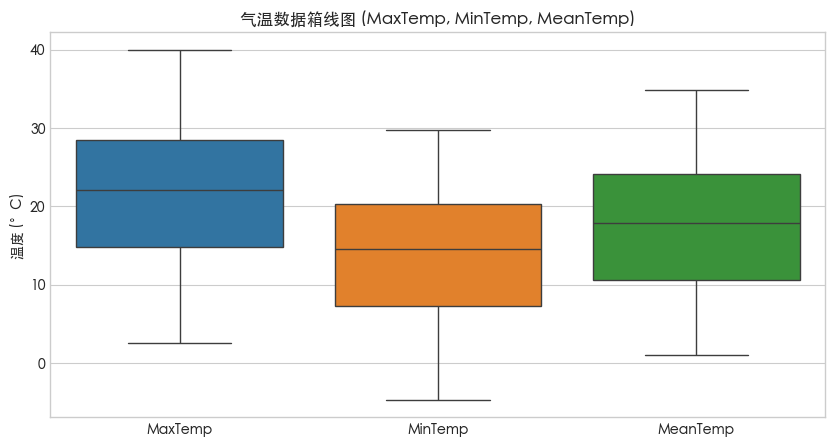


【清洗总结】
Date         0
MaxTemp      0
MinTemp      0
MeanTemp     0
Precip       0
WindSpeed    0
Radiation    0
dtype: int64


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# df_clean 是数据副本
df_clean = df_chengdu.copy()

print("【第一步：逻辑硬规则清洗 (物理极值)】")
# 1. 气温：成都历史极端范围放宽到 -10 ~ 40 度
for col in ['MaxTemp', 'MinTemp', 'MeanTemp']:
    df_clean.loc[(df_clean[col] < -10) | (df_clean[col] > 40), col] = np.nan

# 2. 降雨：0 ~ 300mm (超300mm视为故障，成都特大暴雨一般也就200-300mm)
df_clean.loc[(df_clean['Precip'] < 0) | (df_clean['Precip'] > 300), 'Precip'] = np.nan

# 3. 风速：0 ~ 150 km/h (超过150km/h视为故障)
df_clean.loc[(df_clean['WindSpeed'] < 0) | (df_clean['WindSpeed'] > 150), 'WindSpeed'] = np.nan

# 4. 辐射：0 ~ 30 MJ/m²
df_clean.loc[(df_clean['Radiation'] < 0) | (df_clean['Radiation'] > 30), 'Radiation'] = np.nan

# 5. 逻辑悖论
df_clean.loc[df_clean['MinTemp'] > df_clean['MaxTemp'], ['MinTemp', 'MaxTemp']] = np.nan

print("物理规则清洗完成。")


print("\n【第二步：统计学清洗 (仅针对气温)】")
temp_cols = ['MaxTemp', 'MinTemp', 'MeanTemp']

# 绘制气温箱线图
plt.figure(figsize=(10, 5))
sns.boxplot(data=df_clean[temp_cols])
plt.title("气温数据箱线图 (MaxTemp, MinTemp, MeanTemp)")
plt.ylabel("温度 (°C)")
plt.show()

for col in temp_cols:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    
    # 使用 3倍 IQR (保守清洗)
    lower = Q1 - 3 * IQR
    upper = Q3 + 3 * IQR
    
    # 标记异常
    mask = (df_clean[col] < lower) | (df_clean[col] > upper)
    if mask.sum() > 0:
        print(f"列 '{col}' 发现 {mask.sum()} 个 IQR 统计异常值，已置空。")
        df_clean.loc[mask, col] = np.nan

print("\n【清洗总结】")
print(df_clean.isnull().sum())

## 2. 数据EDA分析

一、数据全貌
1. 样本总量: 2192 天
2. 时间跨度: 2019-01-01 至 2024-12-31

3. 描述性统计 (Descriptive Statistics):
       MaxTemp  MinTemp  MeanTemp   Precip  WindSpeed  Radiation
count  2192.00  2192.00   2192.00  2192.00    2192.00    2192.00
mean     21.61    13.82     17.46     3.22      12.54      11.80
std       8.11     7.45      7.60     9.20       4.75       5.93
min       2.50    -4.70      1.00     0.00       3.30       1.30
25%      14.80     7.20     10.60     0.00       9.20       6.94
50%      22.10    14.60     17.90     0.40      11.30      10.98
75%      28.50    20.30     24.10     2.60      14.50      16.51
max      40.00    29.80     34.80   142.50      36.00      26.41


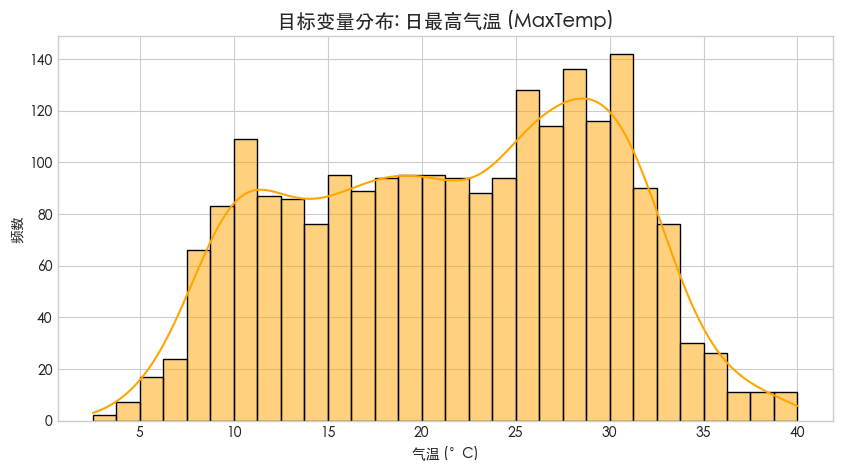

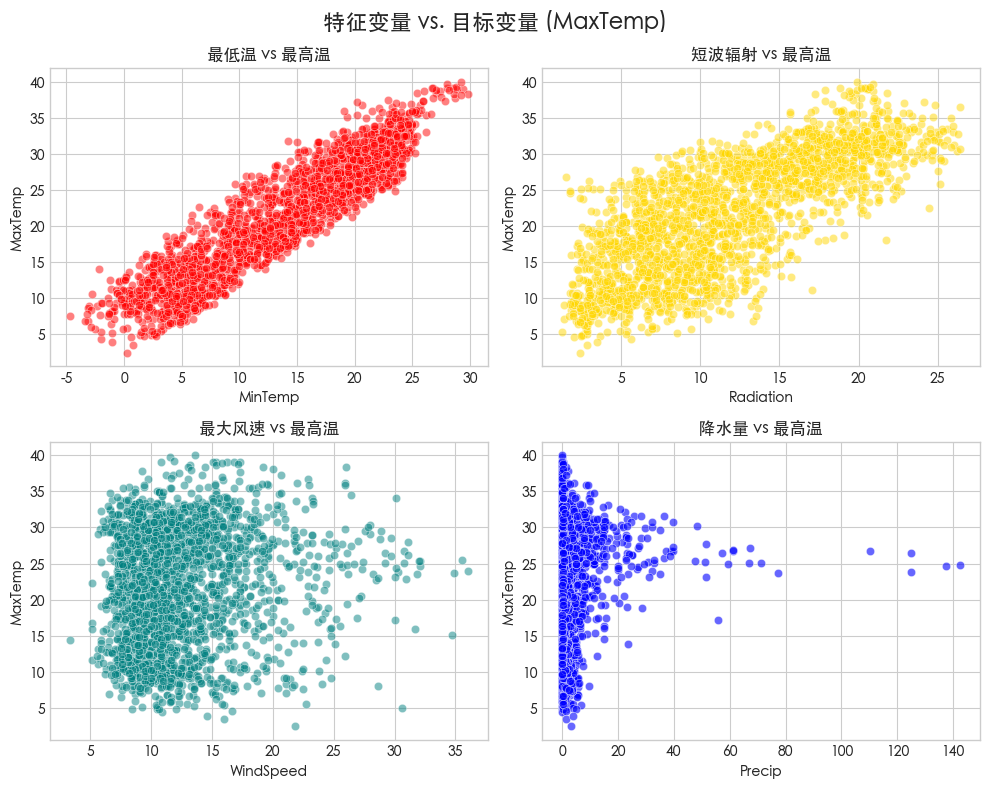

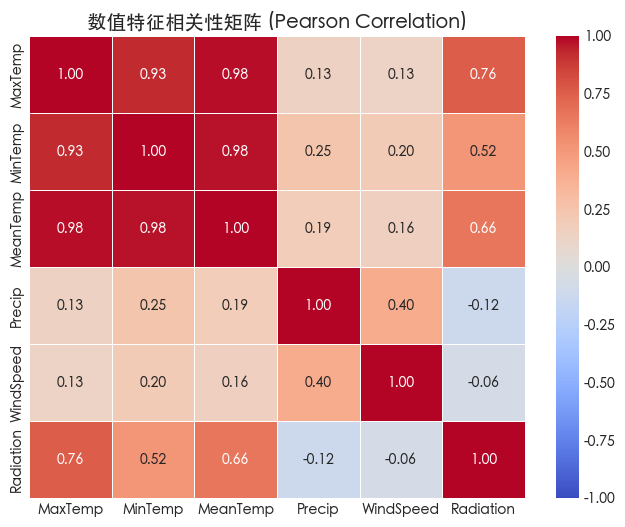

图解：关注颜色最深（接近1或-1）的格子。注意 MaxTemp 与 MinTemp/MeanTemp 高度相关，存在多重共线性风险。


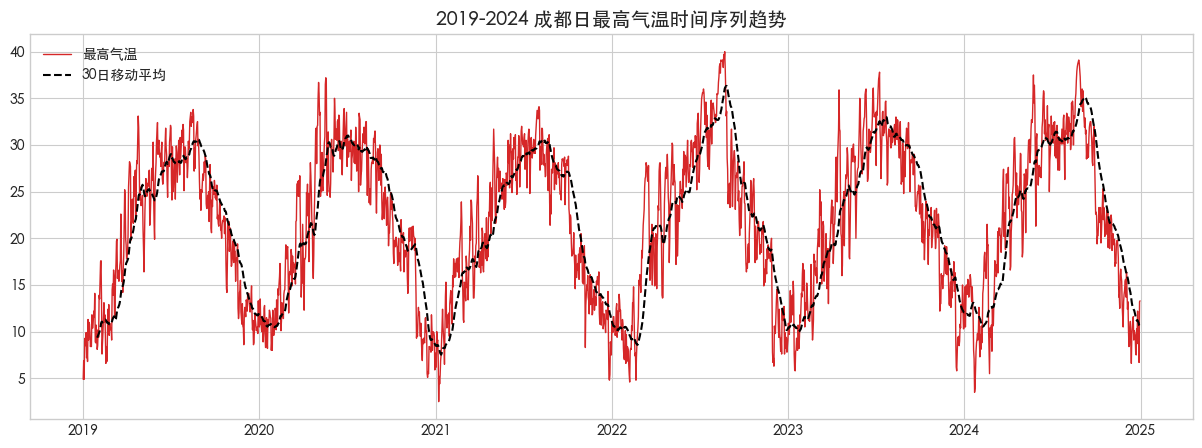

/var/folders/m8/4htghw4x28sg8j9czpx3vbq00000gn/T/ipykernel_73093/2492241950.py:74: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_eda, x='Month', y='MaxTemp', palette='coolwarm')


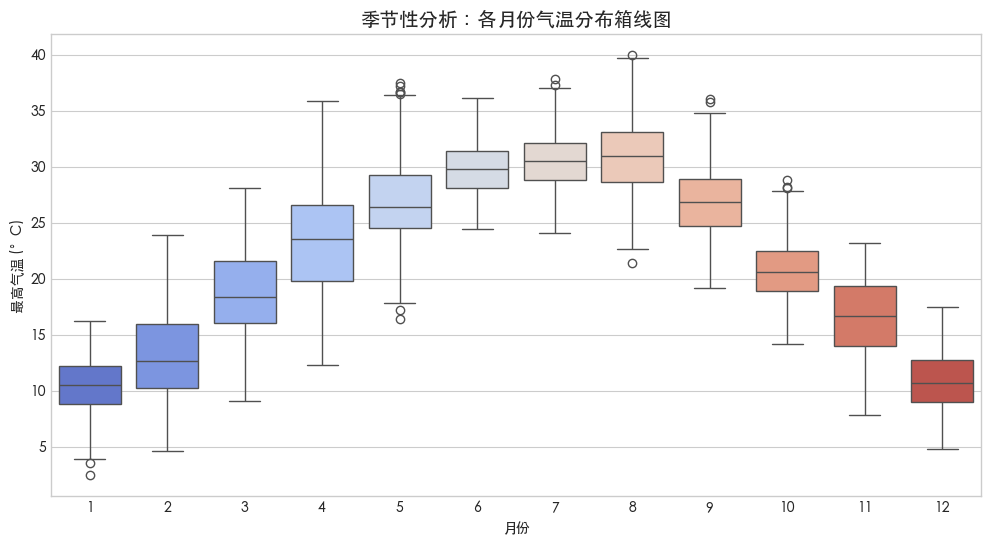

图解：观察箱体的高低变化，验证成都“冬冷夏热”的季节性规律。


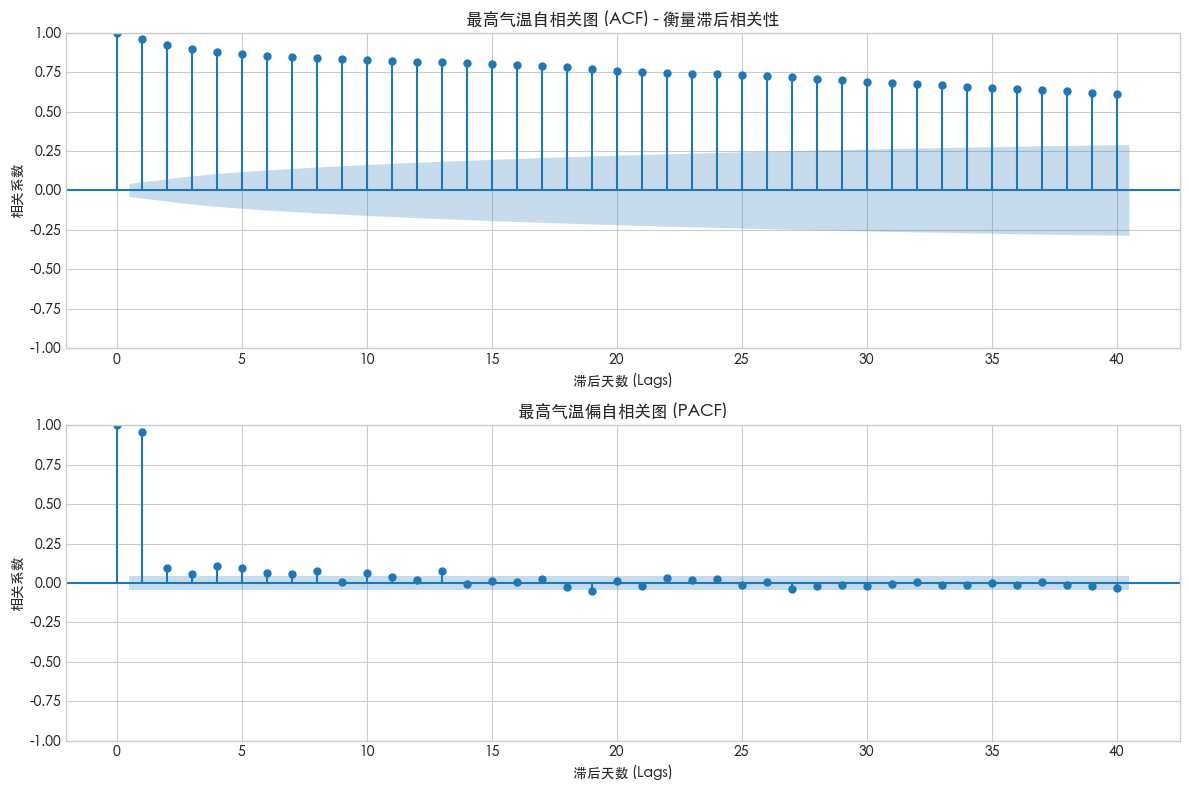

图解：如果 ACF 图（上图）前面的柱子很高且缓慢下降，说明气温具有很强的“惯性”，非常适合做时间序列预测。


In [15]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

df_eda = df_clean.copy()

# 确保日期是 datetime 格式并设为索引（方便时间序列绘图）
df_eda['Date'] = pd.to_datetime(df_eda['Date'])
df_eda.set_index('Date', inplace=True)

# 设置绘图风格 (中文支持)
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.sans-serif'] = ['Heiti TC']  # 用来正常显示中文标签
plt.rcParams['axes.unicode_minus'] = False  # 用来正常显示负号

print("一、数据全貌")
print(f"1. 样本总量: {df_eda.shape[0]} 天")
print(f"2. 时间跨度: {df_eda.index.min().date()} 至 {df_eda.index.max().date()}")
print("\n3. 描述性统计 (Descriptive Statistics):")
desc_stats = df_eda[['MaxTemp', 'MinTemp', 'MeanTemp', 'Precip', 'WindSpeed', 'Radiation']].describe().round(2)
print(desc_stats)


# 二、 目标变量分布 
plt.figure(figsize=(10, 5))
sns.histplot(df_eda['MaxTemp'], kde=True, color='orange', bins=30)
plt.title('目标变量分布: 日最高气温 (MaxTemp)', fontsize=14)
plt.xlabel('气温 (°C)')
plt.ylabel('频数')
plt.show()


# 三、 特征与目标的关系
# 1. 散点图 
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
fig.suptitle('特征变量 vs. 目标变量 (MaxTemp)', fontsize=16)
# 温度之间
sns.scatterplot(data=df_eda, x='MinTemp', y='MaxTemp', ax=axes[0, 0], alpha=0.5, color='r')
axes[0, 0].set_title('最低温 vs 最高温')
# 辐射 vs 气温
sns.scatterplot(data=df_eda, x='Radiation', y='MaxTemp', ax=axes[0, 1], alpha=0.5, color='gold')
axes[0, 1].set_title('短波辐射 vs 最高温')
# 风速 vs 气温
sns.scatterplot(data=df_eda, x='WindSpeed', y='MaxTemp', ax=axes[1, 0], alpha=0.5, color='teal')
axes[1, 0].set_title('最大风速 vs 最高温')
# 降雨 vs 气温 
sns.scatterplot(data=df_eda, x='Precip', y='MaxTemp', ax=axes[1, 1], alpha=0.6, color='blue')
axes[1, 1].set_title('降水量 vs 最高温')
plt.tight_layout()
plt.show()

# 2. 相关性热力图 - 多重共线性探索
plt.figure(figsize=(8, 6))
corr_matrix = df_eda[['MaxTemp', 'MinTemp', 'MeanTemp', 'Precip', 'WindSpeed', 'Radiation']].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5, vmin=-1, vmax=1)
plt.title('数值特征相关性矩阵', fontsize=14)
plt.show()


# 四、 时间序列模式分析 
# 1. 整体趋势 
plt.figure(figsize=(15, 5))
plt.plot(df_eda.index, df_eda['MaxTemp'], label='最高气温', color='tab:red', linewidth=1)
# 加上移动平均线看趋势
plt.plot(df_eda.index, df_eda['MaxTemp'].rolling(window=30).mean(), label='30日移动平均', color='black', linestyle='--', linewidth=1.5)
plt.title('2019-2024 成都日最高气温时间序列趋势', fontsize=14)
plt.legend()
plt.show()

# 2. 季节性分析 
# 提取月份
df_eda['Month'] = df_eda.index.month

plt.figure(figsize=(12, 6))
sns.boxplot(data=df_eda, x='Month', y='MaxTemp', palette='coolwarm')
plt.title('季节性分析：各月份气温分布箱线图', fontsize=14)
plt.xlabel('月份')
plt.ylabel('最高气温 (°C)')
plt.show()

# 3. 自相关性分析 (ACF & PACF)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))

# ACF (自相关函数)：展示今天气温与过去n天的相关性
plot_acf(df_eda['MaxTemp'], lags=40, ax=ax1, title='最高气温自相关图 (ACF) - 衡量滞后相关性')
ax1.set_xlabel('滞后天数 (Lags)')
ax1.set_ylabel('相关系数')

# PACF (偏自相关函数)：剔除中间影响后，今天与过去n天的直接相关性
plot_pacf(df_eda['MaxTemp'], lags=40, ax=ax2, title='最高气温偏自相关图 (PACF)')
ax2.set_xlabel('滞后天数 (Lags)')
ax2.set_ylabel('相关系数')
plt.tight_layout()
plt.show()

## EDA 总结与挖掘策略启示

基于上述探索性数据分析，我们得出以下关键结论，并将指导后续的特征工程与建模过程：

### （1）数据分布特性：非线性
* **结论**：目标变量 `MaxTemp` 呈现显著的**双峰分布**，表明数据内部存在复杂的非线性模式。
* **策略**：简单的线性模型（如 Linear Regression）可能难以捕捉这种复杂分布。因此，本研究将引入**集成学习模型：XGBoost**作为主模型，利用其强大的非线性拟合能力来提升预测精度。

### （2）特征相关性：共线性与冗余
* **结论**：`MinTemp`、`MeanTemp` 与 `MaxTemp` 之间存在极强的正相关性（Pearson系数 > 0.9），存在多重共线性风险。
* **策略**：
    * 对于线性基准模型，需进行特征筛选，剔除冗余变量（如移除 MeanTemp）。
    * 对于树模型（XGBoost），由于其对共线性具有天然的鲁棒性，我们将**保留所有温度特征**，让模型自动学习最优分裂点。

### （3）时间序列特性：惯性与周期
* **结论**：自相关图（ACF）显示气温具有很强的持续性（Inertia），即“昨天的天气很大程度上决定了今天”。同时，月度箱线图展示了明显的季节性周期。
* **策略（特征工程核心）**：
    * **构造滞后特征**：引入 $T-1, T-2, T-7$ 时刻的气温作为输入特征，捕捉数据的自相关性。
    * **构造时间特征**：从日期中提取 `Month`（月份）和 `DayOfYear`，辅助模型识别季节性规律。
    * **验证方式**：采用**时间序列切分** 而非随机打乱，严防未来数据泄露。

## 3. 特征工程

在将时间序列数据输入到监督学习模型（如线性回归或 XGBoost）之前，我们需要构建能够反映“时间依赖性”和“季节性”的特征。本环节是提升模型预测精度的核心步骤，主要包含以下策略：

### 基础时间特征提取
从 `Date` 字段中提取出月份 (`Month`)、日期 (`Day`) 和一年中的第几天 (`DayOfYear`)。这些特征能帮助模型识别基本的季节性模式（例如：7月通常比1月热）。

### 周期性编码 
**目的**：解决时间特征的连续性问题。
* **问题**：对于线性模型，月份 "12" 和 "1" 在数值上相差很大，但在现实中它们是相邻的（跨年）。
* **解决方案**：利用三角函数将时间特征映射到圆形坐标系上：
    * $Month\_Sin = \sin(2 \pi \times Month / 12)$
    * $Month\_Cos = \cos(2 \pi \times Month / 12)$
    * 这样可以保留时间的周期性结构，对线性回归模型尤为重要。

### 滞后特征 —— 捕捉自相关性
**核心逻辑**：利用“过去”预测“未来”。
由于气温具有很强的惯性（今天的气温很大程度上取决于昨天），我们构造了滞后特征：
* `Lag_1`：昨天的数值（T-1）。
* `Lag_2`：前天的数值（T-2）。
* `Lag_7`：上周同期的数值（T-7）。
* **涵盖变量**：除了气温，我们还引入了最低温 (`MinTemp`) 和辐射量 (`Radiation`) 的滞后特征，以捕捉多变量间的时序影响。

### 滑动窗口统计特征 
**目的**：平滑短期波动，捕捉近期趋势。
计算过去一段时间（如3天、7天）的统计量，例如：
* `Roll_Mean_3`：过去3天的平均最高气温，反映短期气温走势。
* `Roll_Max_3`：过去3天的最高气温极值，捕捉近期是否有热浪事件。

### 目标变量构建与数据清洗
* **目标变量 (Target)**：将 `MaxTemp` 向上平移一行 (`shift(-1)`)，作为模型需要预测的“明天最高气温”。
* **缺失值清洗**：由于 `shift` 和 `rolling` 操作会导致数据首尾产生缺失值 (`NaN`)，在建模前需剔除这些无法使用的行，以确保训练数据的完整性。

In [30]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
import xgboost as xgb

# 确保按时间排序，这是时间序列特征工程的前提
df_model = df_clean.sort_values('Date').reset_index(drop=True)

# ==========================================
# 1. 特征工程流水线
# ==========================================

# A. 基础时间特征 
# 目的：模型不认识"2023-07-15"这样的日期格式，但它能理解数字。这一步是为了从日期中提取出最基本的周期性信息，比如月份（代表季节）、一年中的第几天。
df_model['Month'] = df_model['Date'].dt.month
df_model['Day'] = df_model['Date'].dt.day
df_model['DayOfYear'] = df_model['Date'].dt.dayofyear

# B. 周期性编码 
# 目的：只用数字 1, 2, ..., 12 表示月份，模型会认为12月和1月之间隔得很远，但实际上它们是紧挨着的。让线性模型理解 12月 和 1月 是相连的
# 公式：sin(2 * pi * x / period), cos(2 * pi * x / period)
df_model['Month_Sin'] = np.sin(2 * np.pi * df_model['Month'] / 12)
df_model['Month_Cos'] = np.cos(2 * np.pi * df_model['Month'] / 12)
df_model['Day_Sin'] = np.sin(2 * np.pi * df_model['DayOfYear'] / 365)
df_model['Day_Cos'] = np.cos(2 * np.pi * df_model['DayOfYear'] / 365)

# C. 滞后特征 
# 目的：利用“过去”预测“未来”。
# df_model[col].shift(1)：这是Pandas的魔法函数。它会把整个列的数据向下移动一行。结果就是，在今天的这一行里，MaxTemp_Lag_1 这个新列存放的是昨天的 MaxTemp 值。
   # shift(7) 就是把数据下移7行，代表获取“上周同一天”的数据。这个循环为好几个关键特征（最高温、最低温等）创建了多个滞后版本（昨天、前天、大前天、上周）。
features_to_lag = ['MaxTemp', 'MinTemp', 'MeanTemp', 'Radiation']
lags = [1, 2, 3, 7] 

for col in features_to_lag:
    for lag in lags:
        col_name = f'{col}_Lag_{lag}'
        df_model[col_name] = df_model[col].shift(lag)

# D. 滑动窗口特征 
# 目的：平滑短期波动，捕捉近期趋势
# shift(1) 是必须的！因为我们在预测“明天”，只能用“昨天及以前”的滑动平均，不能包含“今天”的（防止数据泄露）
window_sizes = [3, 7]
for window in window_sizes:
    # 计算过去N天的最高温均值
    df_model[f'MaxTemp_Roll_Mean_{window}'] = df_model['MaxTemp'].rolling(window=window).mean().shift(1)
    # 计算过去N天的最高温最大值（捕捉近期是否出现极端热浪）
    df_model[f'MaxTemp_Roll_Max_{window}'] = df_model['MaxTemp'].rolling(window=window).max().shift(1)

# E. 构建目标变量 
# 任务：利用 T时刻及之前的特征，预测 T+1 时刻的 MaxTemp
df_model['Target'] = df_model['MaxTemp'].shift(-1)

# F. 最终清洗 
# 因为 shift(7) 会导致前7行数据缺失 Lag_7 特征
# shift(-1) 会导致最后1行数据缺失 Target
# 我们必须删除这些无法用于训练的行
print(f"特征构造前样本量: {len(df_model)}")
df_model.dropna(inplace=True)
print(f"特征构造后样本量 (用于建模): {len(df_model)}")

# G. 特征列表确认
# 我们只选择构造好的特征进入模型，排除原始的 Date 和 Target
feature_cols = [
    # 1. 原始数值特征 (当天的天气状况)
    'Precip', 'WindSpeed', 'Radiation', 'MinTemp', 'MeanTemp',
    # 2. 周期性时间特征
    'Month_Sin', 'Month_Cos', 'Day_Sin', 'Day_Cos',
    # 3. 滞后特征 (最重要的部分)
    'MaxTemp_Lag_1', 'MaxTemp_Lag_2', 'MaxTemp_Lag_3', 'MaxTemp_Lag_7',
    'MinTemp_Lag_1', 'Radiation_Lag_1',
    # 4. 滑动特征
    'MaxTemp_Roll_Mean_3', 'MaxTemp_Roll_Mean_7', 'MaxTemp_Roll_Max_3'
]

print(f"\n最终入模特征列表 (共 {len(feature_cols)} 个):")
print(feature_cols)

正在构建特征工程流水线...
特征构造前样本量: 2192
特征构造后样本量 (用于建模): 2184

最终入模特征列表 (共 18 个):
['Precip', 'WindSpeed', 'Radiation', 'MinTemp', 'MeanTemp', 'Month_Sin', 'Month_Cos', 'Day_Sin', 'Day_Cos', 'MaxTemp_Lag_1', 'MaxTemp_Lag_2', 'MaxTemp_Lag_3', 'MaxTemp_Lag_7', 'MinTemp_Lag_1', 'Radiation_Lag_1', 'MaxTemp_Roll_Mean_3', 'MaxTemp_Roll_Mean_7', 'MaxTemp_Roll_Max_3']
